# Selected lncRNA Validation

Per-gene correspondence plots and match summaries for 6 hand-picked lncRNAs
(MALAT1, NEAT1, XIST, H19, XACT, KCNQ1OT1) projected from human (hg38) to mouse (mm39).

For each gene:
- **Correspondence plot** — reference vs query islands, connected sub-region bands with MMD scores
- **Match table** — matched pairs with aligned core lengths and MMD

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Polygon

from pyrion.io.bed import read_bed12_file

SELECTED_GENES = {
    "U_ENSG00000251562": "MALAT1",
    "U_ENSG00000245532": "NEAT1",
    "U_ENSG00000229807": "XIST",
    "U_ENSG00000130600": "H19",
    "U_ENSG00000241743": "XACT",
    "U_ENSG00000269821": "KCNQ1OT1",
}

MIN_ISLAND_LEN = 72

PIPELINE_DIR = Path("../quick_test")

In [2]:
with open(PIPELINE_DIR / "preprocessed_reference_data.json") as f:
    all_ref_data = json.load(f)

with open(PIPELINE_DIR / "mappings" / "query_regions_clusters.json") as f:
    query_clusters = json.load(f)

with open(PIPELINE_DIR / "mappings" / "union_to_query.json") as f:
    union_to_query = json.load(f)

ref_union_bed = read_bed12_file(str(PIPELINE_DIR / "union_transcripts.bed"))
query_islands_bed = read_bed12_file(str(PIPELINE_DIR / "intermediate_bed_files" / "raw_query_islands.bed"))
alignment_df = pd.read_csv(PIPELINE_DIR / "island_alignment_results.tsv", sep="\t")

print(f"Alignment results: {len(alignment_df)} total")
print(f"Selected genes: {', '.join(SELECTED_GENES.values())}")

Alignment results: 217 total
Selected genes: MALAT1, NEAT1, XIST, H19, XACT, KCNQ1OT1


## Overview

In [3]:
overview_rows = []
for gene_id, gene_name in sorted(SELECTED_GENES.items(), key=lambda x: x[1]):
    ref_t = ref_union_bed.get_by_id(gene_id)
    if ref_t is None:
        continue

    gene_data = all_ref_data.get(gene_id, {})
    raw_islands = gene_data.get("islands", [])
    ref_islands = [isl for isl in raw_islands if isl["end"] - isl["start"] >= MIN_ISLAND_LEN]

    qr_ids = union_to_query.get(gene_id, [])
    n_query_islands = 0
    for t in query_islands_bed:
        if t.id.startswith(gene_id + "."):
            if int(t.end - t.start) >= MIN_ISLAND_LEN:
                n_query_islands += 1

    gene_align = alignment_df[alignment_df["gene_id"] == gene_id]
    n_matched = len(gene_align)
    median_mmd = gene_align["diag_mmd"].median() if n_matched > 0 else float("nan")

    ref_loc = f"{ref_t.chrom}:{int(ref_t.start):,}-{int(ref_t.end):,}"

    overview_rows.append({
        "gene": gene_name,
        "ref_location": ref_loc,
        "ref_strand": ref_t.strand,
        "ref_islands": len(ref_islands),
        "query_islands": n_query_islands,
        "matched": n_matched,
        "median_mmd": round(median_mmd, 4) if not np.isnan(median_mmd) else "—",
    })

overview_df = pd.DataFrame(overview_rows)
print(overview_df.to_string(index=False))

    gene                 ref_location  ref_strand  ref_islands  query_islands  matched  median_mmd
     H19    chr11:1,995,175-1,997,842          -1            3             12        2      0.0788
KCNQ1OT1    chr11:2,608,327-2,699,994          -1          121             80       48      0.0612
  MALAT1  chr11:65,497,605-65,508,073           1           11             13        7      0.0487
   NEAT1  chr11:65,422,797-65,445,540           1           35             54       19      0.0775
    XACT chrX:113,616,299-113,991,976          -1          211             58       18      0.0618
    XIST   chrX:73,820,655-73,852,714          -1           11              7        5      0.0747


## Per-Gene Correspondence

H19 (U_ENSG00000130600)
Ref: chr11:1,995,175-1,997,842 (strand -1)
Query: chr7:142,128,796-142,133,383 (strand -1)
Ref islands: 3, Query islands: 12, Matches: 2

Match        Ref region           Query region         Core (nt)    MMD     
------------------------------------------------------------------------
R0→Q1        1,995,274-1,995,442  142,129,375-142,129,479 104/104      0.1124  
R2→Q8        1,996,686-1,997,814  142,131,727-142,131,847 132/120      0.0453  



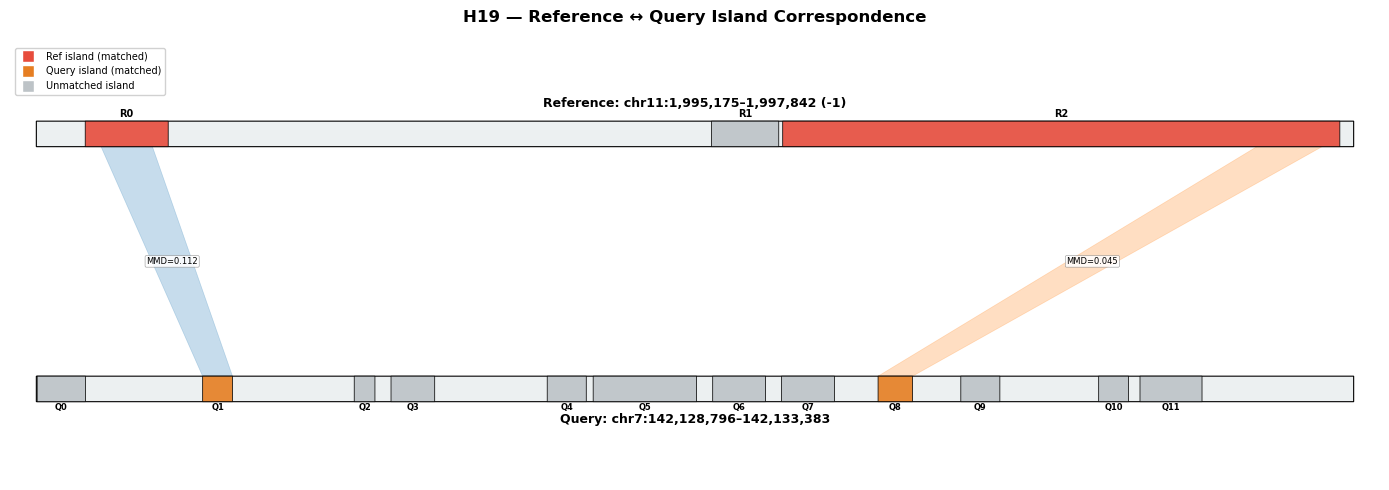

KCNQ1OT1 (U_ENSG00000269821)
Ref: chr11:2,608,327-2,699,994 (strand -1)
Query: chr7:142,803,667-142,850,696 (strand -1)
Ref islands: 121, Query islands: 80, Matches: 48

Match        Ref region           Query region         Core (nt)    MMD     
------------------------------------------------------------------------
R100→Q56     2,688,370-2,689,226  142,838,431-142,838,503 96/72        0.1080  
R101→Q58     2,689,250-2,689,514  142,839,007-142,839,143 112/112      0.0583  
R102→Q59     2,689,618-2,690,218  142,839,455-142,839,719 188/228      0.0742  
R105→Q60     2,691,058-2,691,226  142,840,447-142,840,583 160/136      0.0364  
R106→Q61     2,691,298-2,691,498  142,840,751-142,840,839 96/88        0.0000  
R107→Q62     2,691,618-2,691,930  142,841,071-142,841,159 96/88        0.1025  
R108→Q63     2,691,938-2,692,234  142,841,311-142,841,383 96/72        0.0719  
R109→Q65     2,692,450-2,692,922  142,841,695-142,841,831 120/120      0.0328  
R109→Q66     2,692,450-2,692,922  142,84

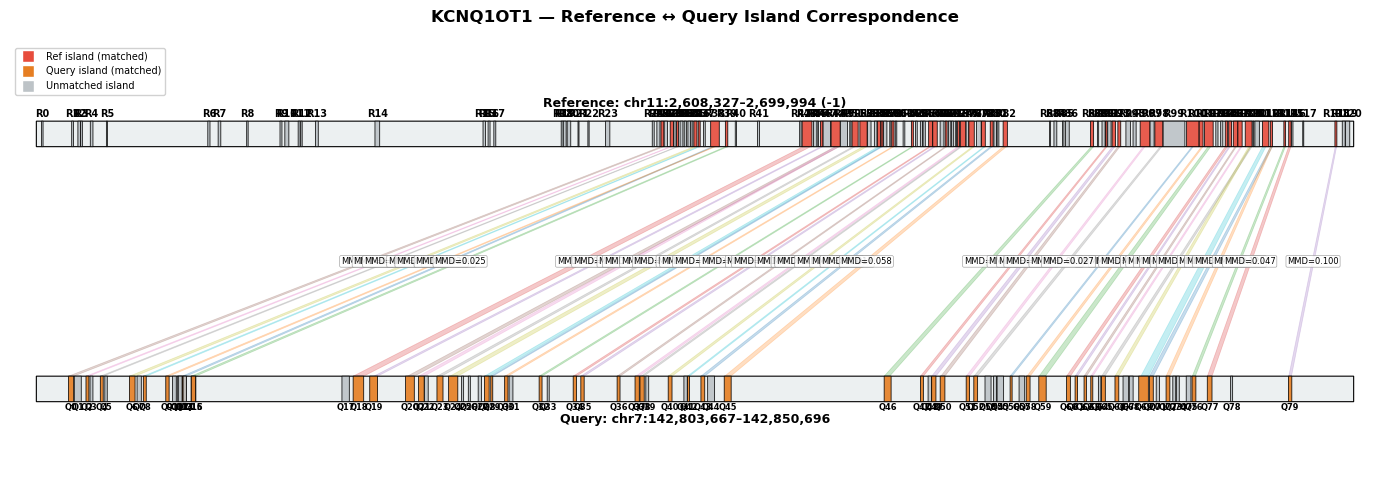

MALAT1 (U_ENSG00000251562)
Ref: chr11:65,497,605-65,508,073 (strand 1)
Query: chr19:5,843,630-5,853,790 (strand -1)
Ref islands: 11, Query islands: 13, Matches: 7

Match        Ref region           Query region         Core (nt)    MMD     
------------------------------------------------------------------------
R0→Q12       65,498,325-65,498,477 5,853,302-5,853,438  108/112      0.1076  
R1→Q11       65,499,029-65,499,117 5,852,614-5,852,734  88/96        0.0319  
R2→Q10       65,501,621-65,501,757 5,850,150-5,850,286  136/132      0.0746  
R5→Q8        65,504,293-65,504,429 5,847,783-5,847,919  136/120      0.0928  
R6→Q4        65,506,773-65,507,085 5,845,149-5,845,365  96/96        0.0487  
R7→Q3        65,507,173-65,507,309 5,845,021-5,845,141  120/120      0.0300  
R8→Q1        65,507,349-65,507,453 5,844,461-5,844,693  104/104      0.0065  



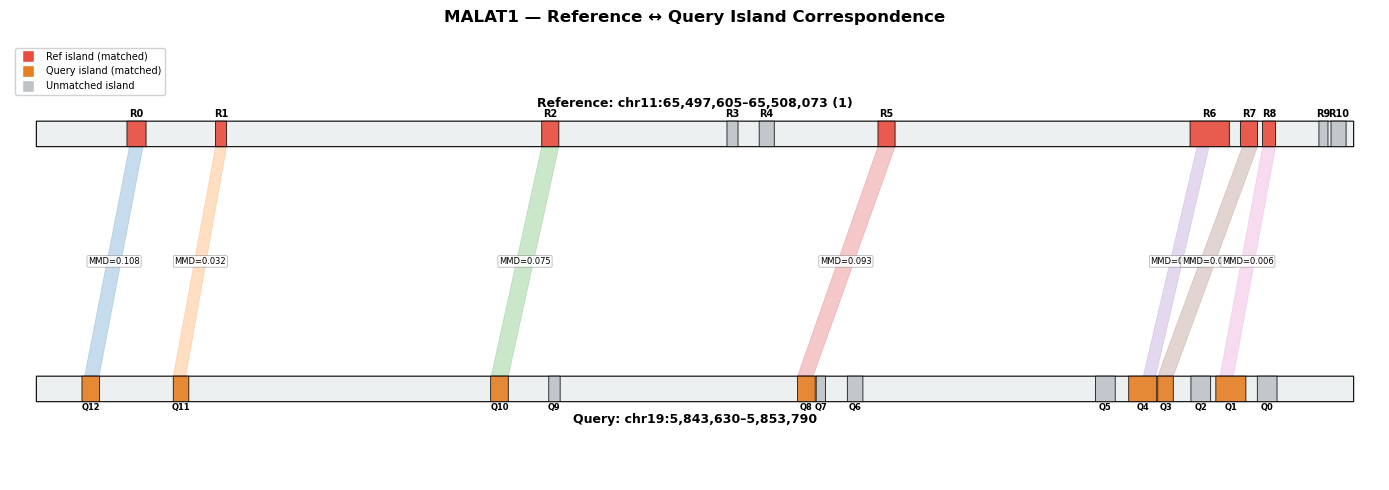

NEAT1 (U_ENSG00000245532)
Ref: chr11:65,422,797-65,445,540 (strand 1)
Query: chr19:5,873,950-5,895,994 (strand -1)
Ref islands: 35, Query islands: 54, Matches: 19

Match        Ref region           Query region         Core (nt)    MMD     
------------------------------------------------------------------------
R1→Q53       65,423,149-65,423,573 5,895,074-5,895,306  184/180      0.0842  
R10→Q38      65,430,125-65,430,245 5,889,522-5,889,690  104/104      0.0775  
R12→Q33      65,435,485-65,435,685 5,886,256-5,886,424  192/168      0.0796  
R13→Q31      65,435,949-65,436,197 5,885,696-5,885,896  224/196      0.0892  
R15→Q30      65,436,541-65,436,677 5,885,472-5,885,592  116/116      0.0569  
R17→Q28      65,437,949-65,438,245 5,883,719-5,883,807  96/88        0.0596  
R18→Q19      65,439,085-65,439,221 5,880,567-5,880,703  136/132      0.1195  
R2→Q51       65,423,805-65,423,941 5,894,498-5,894,570  96/72        0.0602  
R22→Q18      65,440,669-65,440,869 5,880,407-5,880,527  96/96 

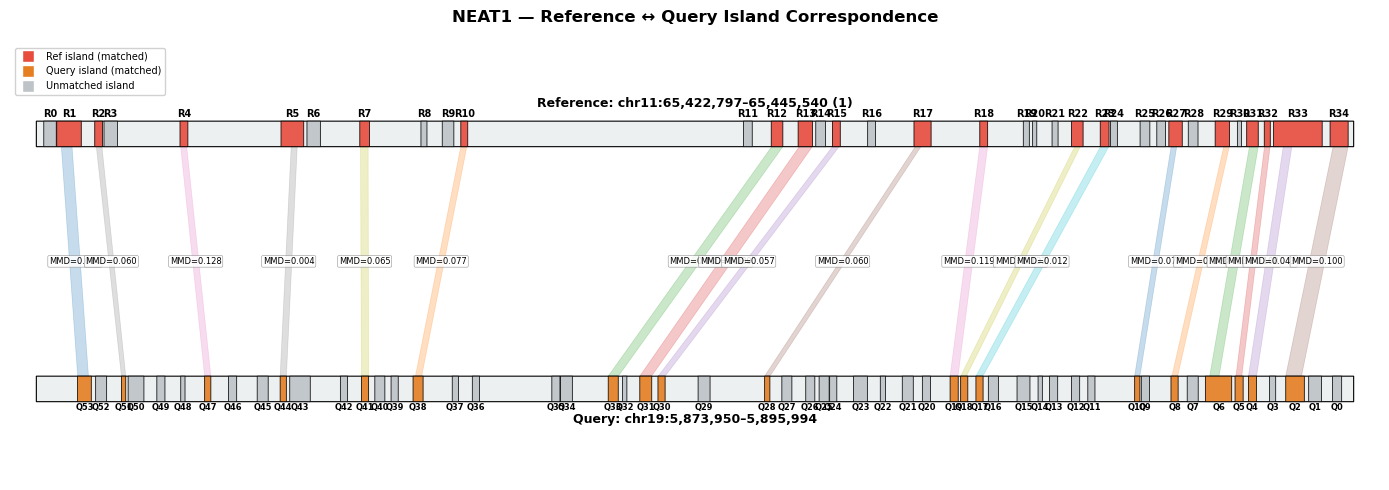

XACT (U_ENSG00000241743)
Ref: chrX:113,616,299-113,991,976 (strand -1)
Query: chrX:145,006,219-145,250,848 (strand -1)
Ref islands: 211, Query islands: 58, Matches: 18

Match        Ref region           Query region         Core (nt)    MMD     
------------------------------------------------------------------------
R108→Q39     113,818,647-113,818,991 145,168,513-145,168,633 128/112      0.0833  
R134→Q41     113,851,175-113,851,247 145,172,730-145,172,850 72/96        0.0729  
R139→Q43     113,863,335-113,863,503 145,187,278-145,187,366 96/88        0.0366  
R156→Q50     113,893,815-113,893,967 145,210,793-145,210,913 120/120      0.0340  
R178→Q52     113,915,847-113,915,919 145,223,100-145,223,204 72/96        0.0146  
R184→Q54     113,919,511-113,919,583 145,232,668-145,232,852 72/96        0.1408  
R184→Q55     113,919,511-113,919,583 145,232,860-145,233,076 72/96        0.1490  
R202→Q57     113,946,775-113,946,911 145,248,632-145,248,704 96/72        0.0000  
R27→Q9       113,

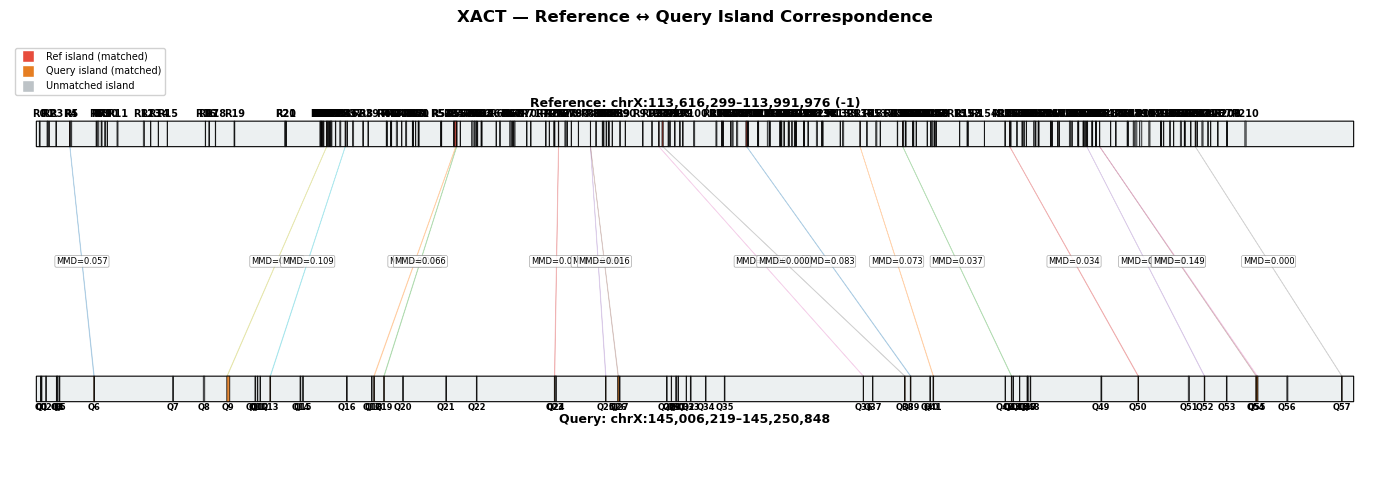

XIST (U_ENSG00000229807)
Ref: chrX:73,820,655-73,852,714 (strand -1)
Query: chrX:102,506,407-102,527,279 (strand -1)
Ref islands: 11, Query islands: 7, Matches: 5

Match        Ref region           Query region         Core (nt)    MMD     
------------------------------------------------------------------------
R0→Q0        73,823,656-73,823,728 102,506,966-102,507,070 72/96        0.0594  
R3→Q2        73,829,112-73,829,216 102,512,326-102,512,430 104/104      0.1217  
R5→Q4        73,843,137-73,843,225 102,519,242-102,519,330 88/88        0.0747  
R5→Q5        73,843,137-73,843,225 102,519,370-102,519,442 88/72        0.0682  
R9→Q6        73,849,793-73,849,977 102,523,779-102,524,059 144/144      0.0787  



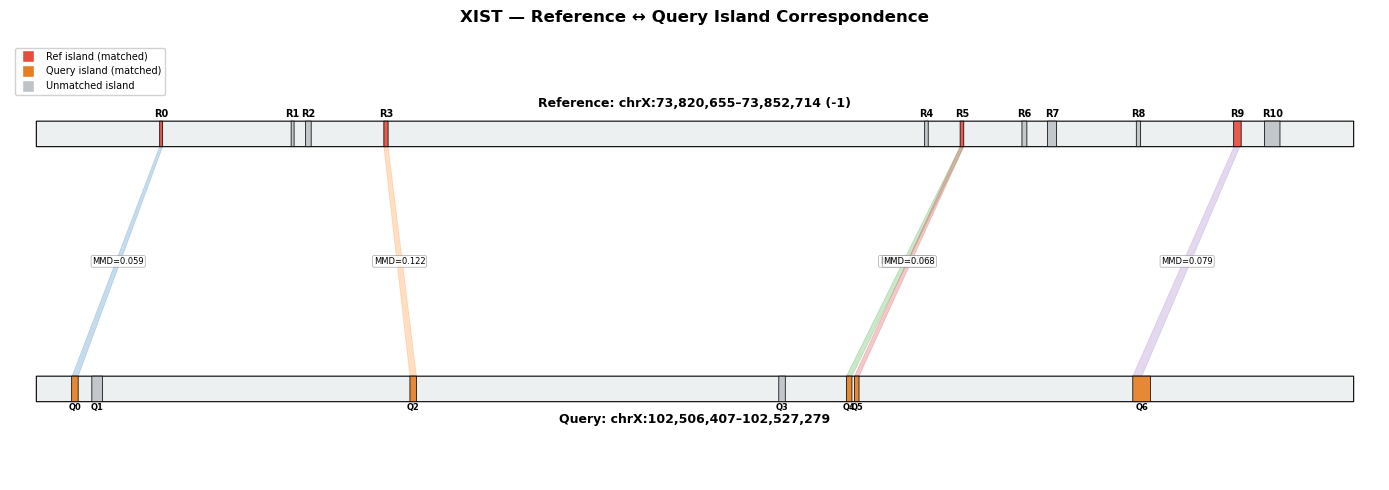

In [4]:
def plot_correspondence(gene_id, gene_name, ref_union_bed, all_ref_data,
                        query_clusters, union_to_query, query_islands_bed,
                        alignment_df, min_island_len=72):
    """Draw a correspondence plot for one gene and print match details."""

    ref_t = ref_union_bed.get_by_id(gene_id)
    if ref_t is None:
        print(f"{gene_name}: not found in reference union BED, skipping.")
        return

    ref_start = int(ref_t.start)
    ref_end = int(ref_t.end)
    ref_chrom = ref_t.chrom
    ref_strand = ref_t.strand
    ref_span = ref_end - ref_start

    # Ref islands (filtered + sorted, same as island_alignment.py)
    gene_data = all_ref_data.get(gene_id, {})
    raw_islands = gene_data.get("islands", [])
    ref_islands = sorted(
        [isl for isl in raw_islands if isl["end"] - isl["start"] >= min_island_len],
        key=lambda x: x["start"],
    )

    # Query regions
    qr_ids = union_to_query.get(gene_id, [])
    qr_rows = []
    for qr_id in qr_ids:
        cluster = query_clusters.get(qr_id, {})
        mr = cluster.get("merged_region", {})
        qr_rows.append({
            "chrom": mr.get("chrom"),
            "start": mr.get("start"),
            "end": mr.get("end"),
            "strand": mr.get("strand"),
        })
    qr_df = pd.DataFrame(qr_rows)

    if qr_df.empty:
        print(f"{gene_name}: no query regions, skipping.")
        return

    q_global_start = qr_df["start"].min()
    q_global_end = qr_df["end"].max()
    q_chrom = qr_df["chrom"].iloc[0]
    q_span = q_global_end - q_global_start

    # Query islands
    gene_query_islands = []
    for t in query_islands_bed:
        if t.id.startswith(gene_id + "."):
            if int(t.end - t.start) >= min_island_len:
                gene_query_islands.append({
                    "chrom": t.chrom,
                    "start": int(t.start),
                    "end": int(t.end),
                    "length": int(t.end - t.start),
                })
    qi_df = pd.DataFrame(gene_query_islands) if gene_query_islands else pd.DataFrame()
    if not qi_df.empty:
        qi_df = qi_df.sort_values("start").reset_index(drop=True)
        qi_df["label"] = ["Q" + str(i) for i in range(len(qi_df))]

    # Alignment data for this gene
    gene_align = alignment_df[alignment_df["gene_id"] == gene_id].copy()
    # Ensure query_island labels match by stripping spaces
    gene_align["query_island"] = gene_align["query_island"].str.strip()

    # Strand-aware normalization
    q_strand_val = qr_df["strand"].iloc[0] if not qr_df.empty else 1
    _flip_query = (ref_strand != q_strand_val)

    def _q_norm(pos):
        n = (pos - q_global_start) / q_span if q_span > 0 else 0
        return (1 - n) if _flip_query else n

    # ---- Print match table ----
    print(f"{'='*60}")
    print(f"{gene_name} ({gene_id})")
    print(f"Ref: {ref_chrom}:{ref_start:,}-{ref_end:,} (strand {ref_strand})")
    print(f"Query: {q_chrom}:{q_global_start:,}-{q_global_end:,} (strand {q_strand_val})")
    print(f"Ref islands: {len(ref_islands)}, Query islands: {len(qi_df)}, Matches: {len(gene_align)}")
    print()

    if not gene_align.empty:
        print(f"{'Match':<12} {'Ref region':<20} {'Query region':<20} {'Core (nt)':<12} {'MMD':<8}")
        print("-" * 72)
        for _, row in gene_align.iterrows():
            ref_isl_s = int(row["ref_start"])
            ref_isl_e = int(row["ref_end"])
            q_isl_s = int(row["query_start"])
            q_isl_e = int(row["query_end"])
            n_chains = int(row["n_chains"])
            for ci in range(1, n_chains + 1):
                rf_col = f"chain{ci}_ref_from"
                rt_col = f"chain{ci}_ref_to"
                qf_col = f"chain{ci}_q_from"
                qt_col = f"chain{ci}_q_to"
                cm_col = f"chain{ci}_mmd"
                if rf_col not in row.index or pd.isna(row[rf_col]):
                    continue
                core_ref_len = int(row[rt_col]) - int(row[rf_col])
                core_q_len = int(row[qt_col]) - int(row[qf_col])
                mmd_val = float(row[cm_col])
                match_label = f"{row['ref_island']}→{row['query_island']}"
                if n_chains > 1:
                    match_label += f" c{ci}"
                ref_region = f"{ref_isl_s:,}-{ref_isl_e:,}"
                q_region = f"{q_isl_s:,}-{q_isl_e:,}"
                core_str = f"{core_ref_len}/{core_q_len}"
                print(f"{match_label:<12} {ref_region:<20} {q_region:<20} {core_str:<12} {mmd_val:<8.4f}")
        print()

    if qi_df.empty or gene_align.empty:
        print("No matches to plot.")
        return

    # ---- Correspondence plot ----
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.1, 1.1)
    ax.axis("off")

    REF_Y = 0.85
    Q_Y = 0.15
    BAR_H = 0.07

    # Background bars
    ax.add_patch(FancyBboxPatch((0, REF_Y - BAR_H/2), 1, BAR_H,
        boxstyle="round,pad=0", facecolor="#ecf0f1", edgecolor="black",
        linewidth=0.8, zorder=1))
    ax.add_patch(FancyBboxPatch((0, Q_Y - BAR_H/2), 1, BAR_H,
        boxstyle="round,pad=0", facecolor="#ecf0f1", edgecolor="black",
        linewidth=0.8, zorder=1))

    ax.text(0.5, REF_Y + BAR_H/2 + 0.03,
            f"Reference: {ref_chrom}:{ref_start:,}\u2013{ref_end:,} ({ref_strand})",
            ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(0.5, Q_Y - BAR_H/2 - 0.03,
            f"Query: {q_chrom}:{q_global_start:,}\u2013{q_global_end:,}",
            ha="center", va="top", fontsize=9, fontweight="bold")

    # Matched sets
    matched_r_set = set(gene_align["ref_island"].str.strip())
    matched_q_set = set(gene_align["query_island"].str.strip())

    # Draw ref islands
    for ri, isl in enumerate(ref_islands):
        s_norm = (isl["start"] - ref_start) / ref_span
        w_norm = (isl["end"] - isl["start"]) / ref_span
        label = f"R{ri}"
        matched = label in matched_r_set
        color = "#e74c3c" if matched else "#bdc3c7"
        ax.add_patch(FancyBboxPatch(
            (s_norm, REF_Y - BAR_H/2), w_norm, BAR_H,
            boxstyle="round,pad=0", facecolor=color, edgecolor="black",
            linewidth=0.6, alpha=0.9, zorder=2))
        ax.text(s_norm + w_norm/2, REF_Y + BAR_H/2 + 0.005, label,
                ha="center", va="bottom", fontsize=7, fontweight="bold")

    # Draw query islands
    for _, qi_row in qi_df.iterrows():
        q_left = _q_norm(qi_row["start"])
        q_right = _q_norm(qi_row["start"] + qi_row["length"])
        x0 = min(q_left, q_right)
        w = abs(q_right - q_left)
        idx_str = qi_row["label"]
        matched = idx_str in matched_q_set
        color = "#e67e22" if matched else "#bdc3c7"
        ax.add_patch(FancyBboxPatch(
            (x0, Q_Y - BAR_H/2), w, BAR_H,
            boxstyle="round,pad=0", facecolor=color, edgecolor="black",
            linewidth=0.6, alpha=0.9, zorder=2))
        ax.text(x0 + w/2, Q_Y - BAR_H/2 - 0.005, idx_str,
                ha="center", va="top", fontsize=6, fontweight="bold")

    # Draw connecting bands
    band_colors = plt.cm.tab10.colors
    for pair_idx, (_, row) in enumerate(gene_align.iterrows()):
        ri_idx = int(row["ref_island"][1:])
        ref_isl_start = int(row["ref_start"])
        ref_isl_end = int(row["ref_end"])

        qi_str = row["query_island"].strip()
        qi_match = qi_df[qi_df["label"] == qi_str]
        if qi_match.empty:
            continue
        q_isl_start = int(row["query_start"])
        q_isl_end = int(row["query_end"])

        band_color = band_colors[pair_idx % len(band_colors)]
        n_chains = int(row["n_chains"])

        for ci in range(1, n_chains + 1):
            rf_col = f"chain{ci}_ref_from"
            rt_col = f"chain{ci}_ref_to"
            qf_col = f"chain{ci}_q_from"
            qt_col = f"chain{ci}_q_to"
            if rf_col not in row.index or pd.isna(row[rf_col]):
                continue

            if ref_strand == -1 or ref_strand == "-":
                r_abs_s = ref_isl_end - int(row[rt_col])
                r_abs_e = ref_isl_end - int(row[rf_col])
            else:
                r_abs_s = ref_isl_start + int(row[rf_col])
                r_abs_e = ref_isl_start + int(row[rt_col])

            if q_strand_val == -1 or q_strand_val == "-":
                q_abs_s = q_isl_end - int(row[qt_col])
                q_abs_e = q_isl_end - int(row[qf_col])
            else:
                q_abs_s = q_isl_start + int(row[qf_col])
                q_abs_e = q_isl_start + int(row[qt_col])

            r_x0 = (r_abs_s - ref_start) / ref_span
            r_x1 = (r_abs_e - ref_start) / ref_span

            q_left = _q_norm(q_abs_s)
            q_right = _q_norm(q_abs_e)
            q_x0 = min(q_left, q_right)
            q_x1 = max(q_left, q_right)

            polygon = Polygon(
                [(r_x0, REF_Y - BAR_H/2), (r_x1, REF_Y - BAR_H/2),
                 (q_x1, Q_Y + BAR_H/2), (q_x0, Q_Y + BAR_H/2)],
                closed=True, facecolor=band_color, edgecolor=band_color,
                alpha=0.25, linewidth=0.5, zorder=0)
            ax.add_patch(polygon)

        # MMD label
        if n_chains > 0 and "chain1_ref_from" in row.index and not pd.isna(row["chain1_ref_from"]):
            c1_rf = int(row["chain1_ref_from"])
            c1_rt = int(row["chain1_ref_to"])
            c1_qf = int(row["chain1_q_from"])
            c1_qt = int(row["chain1_q_to"])
            if ref_strand == -1 or ref_strand == "-":
                r_mid_abs = ref_isl_end - (c1_rf + c1_rt) / 2
            else:
                r_mid_abs = ref_isl_start + (c1_rf + c1_rt) / 2
            if q_strand_val == -1 or q_strand_val == "-":
                q_mid_abs = q_isl_end - (c1_qf + c1_qt) / 2
            else:
                q_mid_abs = q_isl_start + (c1_qf + c1_qt) / 2
            mid_x = ((r_mid_abs - ref_start) / ref_span + _q_norm(q_mid_abs)) / 2
            mid_y = (REF_Y + Q_Y) / 2
            mmd_val = float(row["diag_mmd"])
            ax.text(mid_x, mid_y, f"MMD={mmd_val:.3f}",
                    ha="center", va="center", fontsize=6,
                    bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                              edgecolor="gray", alpha=0.85, linewidth=0.4))

    # Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#e74c3c",
               markersize=8, label="Ref island (matched)"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#e67e22",
               markersize=8, label="Query island (matched)"),
        Line2D([0], [0], marker="s", color="w", markerfacecolor="#bdc3c7",
               markersize=8, label="Unmatched island"),
    ]
    ax.legend(handles=legend_elements, loc="upper left", fontsize=7,
              framealpha=0.9)

    ax.set_title(f"{gene_name} \u2014 Reference \u2194 Query Island Correspondence",
                 fontsize=12, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.show()


# Plot all selected genes
for gene_id, gene_name in sorted(SELECTED_GENES.items(), key=lambda x: x[1]):
    plot_correspondence(
        gene_id, gene_name, ref_union_bed, all_ref_data,
        query_clusters, union_to_query, query_islands_bed,
        alignment_df, min_island_len=MIN_ISLAND_LEN,
    )